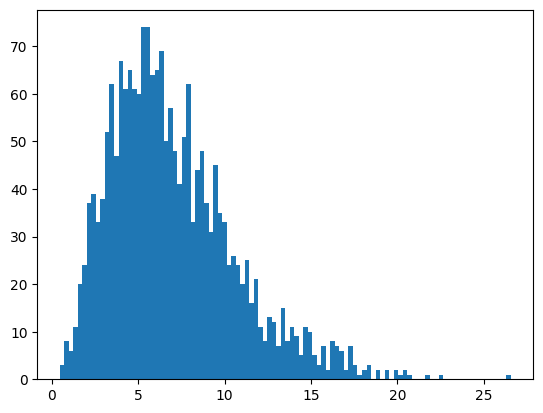

In [4]:
import numpy as np
import matplotlib.pyplot as plt


rng = np.random.default_rng(seed=42)
m = 2000  # number of instances

boylar = rng.normal(175, 10, size=(m,1))
yashlar = rng.uniform(18, 60, size=(m,1))
# maashlar = rng.exponential(scale=4, size=(m,1))
# maashlar = rng.chisquare(df=6, size=(m,1))
maashlar = rng.gamma(shape=3.5, scale=2, size=(m,1))

plt.hist(maashlar, bins=100)
plt.show()

In [5]:
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([boylar/100, yashlar/100])
X_b = add_dummy_feature(X)
# X_b = np.c_[X, np.ones((m, 1))]

y = maashlar/10

X_b, y

(array([[1.        , 1.78047171, 0.19778537],
        [1.        , 1.64600159, 0.36687386],
        [1.        , 1.82504512, 0.40973487],
        ...,
        [1.        , 1.740846  , 0.23681841],
        [1.        , 1.69691782, 0.56835309],
        [1.        , 1.97141526, 0.38183515]], shape=(2000, 3)),
 array([[0.61006609],
        [0.64261833],
        [0.39956131],
        ...,
        [0.39419609],
        [1.47388686],
        [0.21100565]], shape=(2000, 1)))

In [6]:
X

array([[1.78047171, 0.19778537],
       [1.64600159, 0.36687386],
       [1.82504512, 0.40973487],
       ...,
       [1.740846  , 0.23681841],
       [1.69691782, 0.56835309],
       [1.97141526, 0.38183515]], shape=(2000, 2))

In [23]:
np.sqrt(((X[0] - X[1])**2).sum())

np.float64(0.2160396510807437)

In [7]:
y

array([[0.61006609],
       [0.64261833],
       [0.39956131],
       ...,
       [0.39419609],
       [1.47388686],
       [0.21100565]], shape=(2000, 1))

In [57]:
y

array([[0.61006609],
       [0.64261833],
       [0.39956131],
       ...,
       [0.39419609],
       [1.47388686],
       [0.21100565]], shape=(2000, 1))

array([[1.78047171, 0.19778537, 0.61006609],
       [1.64600159, 0.36687386, 0.64261833],
       [1.82504512, 0.40973487, 0.39956131],
       ...,
       [1.740846  , 0.23681841, 0.39419609],
       [1.69691782, 0.56835309, 1.47388686],
       [1.97141526, 0.38183515, 0.21100565]], shape=(2000, 3))

In [64]:
import pandas as pd
df = pd.DataFrame(np.concat([X, np.where(y > 1.1, 1, 0)], axis=1))
df

,0,1,2
0,1.780472,0.197785,0.0
1,1.646002,0.366874,0.0
2,1.825045,0.409735,0.0
3,1.844056,0.241632,0.0
4,1.554896,0.321240,1.0
...,...,...,...
1995,1.789201,0.365804,0.0
1996,1.780384,0.496470,0.0
1997,1.740846,0.236818,0.0
1998,1.696918,0.568353,1.0


In [67]:
mask1 = df[0].between(1.62, 1.66)
mask2 = df[1].between(0.34, 0.38)
df.loc[mask1 & mask2, :]

,0,1,2
1,1.646002,0.366874,0.0
277,1.638759,0.349375,1.0
520,1.652985,0.346347,0.0
557,1.646774,0.371833,0.0
590,1.627763,0.360009,0.0
628,1.645941,0.378190,0.0
653,1.639626,0.345187,0.0
819,1.636057,0.354238,0.0
832,1.637222,0.348549,0.0
975,1.645841,0.345165,1.0


In [18]:
from sklearn.metrics import pairwise_distances
distances = pairwise_distances(X, X, metric='l2') 
pd.DataFrame(distances)


,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,0.000000,0.216040,0.216586,0.077237,0.257148,0.428312,0.020813,0.183118,0.337664,0.165493,...,0.147410,0.116327,0.337964,0.155999,0.327985,0.168245,0.298685,0.055622,0.379871,0.265205
1,0.216040,0.000000,0.184102,0.234331,0.101895,0.229441,0.214613,0.072444,0.195887,0.054164,...,0.144742,0.167892,0.211336,0.202428,0.194271,0.143204,0.186692,0.160965,0.207813,0.325757
2,0.216586,0.184102,0.000000,0.169174,0.284274,0.276381,0.231450,0.113811,0.145971,0.185717,...,0.074107,0.100259,0.136203,0.073813,0.132998,0.056699,0.097559,0.192327,0.203903,0.149005
3,0.077237,0.234331,0.169174,0.000000,0.299918,0.418372,0.098030,0.179688,0.307563,0.194182,...,0.117033,0.080357,0.302463,0.097513,0.295970,0.135749,0.262672,0.103323,0.358324,0.189413
4,0.257148,0.101895,0.284274,0.299918,0.000000,0.281161,0.247562,0.170611,0.287477,0.109922,...,0.235373,0.249822,0.305977,0.292168,0.288290,0.238505,0.285570,0.204216,0.285017,0.420903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.168245,0.143204,0.056699,0.135749,0.238505,0.284864,0.180926,0.070953,0.173011,0.134083,...,0.020859,0.056333,0.170622,0.063225,0.162128,0.000000,0.130964,0.137751,0.222581,0.182918
1996,0.298685,0.186692,0.097559,0.262672,0.285570,0.188319,0.310153,0.140806,0.049297,0.214335,...,0.151774,0.186444,0.039859,0.170689,0.035825,0.130964,0.000000,0.262645,0.110153,0.222787
1997,0.055622,0.160965,0.192327,0.103323,0.204216,0.377910,0.054603,0.135116,0.297191,0.109885,...,0.118394,0.098223,0.300594,0.147074,0.288793,0.137751,0.262645,0.000000,0.334432,0.272382
1998,0.379871,0.207813,0.203903,0.358324,0.285017,0.081548,0.387180,0.199457,0.061872,0.254364,...,0.241669,0.278397,0.082958,0.273734,0.075516,0.222581,0.110153,0.334432,0.000000,0.331870


In [27]:
np.argmin(distances[1, :])

np.int64(1)

In [31]:
distances[1, :]

array([0.21603965, 0.        , 0.18410229, ..., 0.16096547, 0.20781324,
       0.32575742], shape=(2000,))

In [41]:
idx = np.argsort(distances[1, :])[:101]
idx

array([   1,  557, 1874,  628, 1425, 1588, 1905,  819, 1231, 1824, 1160,
        277, 1415,  590,  832, 1218, 1942, 1694,  520,  975,  653,  756,
        284,  890,  367, 1299,  586,   17,  127,   96, 1010, 1946, 1847,
        909, 1001, 1678, 1927, 1252,  207,  259, 1554, 1185,  477, 1487,
        883,  131,  399,  317, 1461,  752, 1939,  194, 1312,  742, 1310,
       1232,  235, 1204,  656,  129, 1516,  814,  113, 1165,   21,  567,
       1501, 1276, 1961, 1107, 1078, 1721,  570, 1859,  428,   52,  424,
       1094, 1661,  363, 1988,  822, 1743, 1500, 1132, 1753,  581, 1891,
       1499,  435, 1566,  115,  541, 1343, 1644, 1196,  159, 1948, 1438,
        910, 1650])

In [42]:
X[idx]

array([[1.64600159, 0.36687386],
       [1.64677373, 0.37183315],
       [1.64355273, 0.36081097],
       [1.64594139, 0.3781899 ],
       [1.65885564, 0.36446912],
       [1.65150051, 0.35458703],
       [1.6339088 , 0.3586775 ],
       [1.6360571 , 0.35423784],
       [1.63772316, 0.38305683],
       [1.66203576, 0.37615779],
       [1.63129296, 0.35501572],
       [1.63875885, 0.3493749 ],
       [1.66478412, 0.36948121],
       [1.62776257, 0.36000903],
       [1.63722192, 0.34854866],
       [1.6304641 , 0.3803748 ],
       [1.62720844, 0.37603623],
       [1.625094  , 0.36531051],
       [1.65298505, 0.34634741],
       [1.64584124, 0.34516506],
       [1.63962593, 0.34518679],
       [1.65791496, 0.38683443],
       [1.63895693, 0.38915928],
       [1.66669633, 0.37815243],
       [1.667775  , 0.35510327],
       [1.65346488, 0.39125801],
       [1.63233853, 0.38855726],
       [1.65411174, 0.39170684],
       [1.63112369, 0.39112532],
       [1.61773004, 0.36242668],
       [1.

In [43]:
y[idx][1:].mean()

np.float64(0.6680740330583471)

In [44]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=100)
knn.fit(X, y)
knn.predict(X[[1]])

array([[0.66430454]])

In [69]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=100)
knn.fit(X, np.where(y > 1.1, 1, 0).ravel())
knn.predict(X[[1]])

array([0])

In [77]:
df

,0,1,2
0,1.780472,0.197785,0.0
1,1.646002,0.366874,0.0
2,1.825045,0.409735,0.0
3,1.844056,0.241632,0.0
4,1.554896,0.321240,1.0
...,...,...,...
1995,1.789201,0.365804,0.0
1996,1.780384,0.496470,0.0
1997,1.740846,0.236818,0.0
1998,1.696918,0.568353,1.0


In [78]:
import pandas as pd
# df = pd.DataFrame(np.concat([X, np.where(y > 1.1, 1, 0)], axis=1))
df = pd.DataFrame(np.concat([X, y], axis=1))
df

,0,1,2
0,1.780472,0.197785,0.610066
1,1.646002,0.366874,0.642618
2,1.825045,0.409735,0.399561
3,1.844056,0.241632,0.434826
4,1.554896,0.321240,1.223068
...,...,...,...
1995,1.789201,0.365804,0.204685
1996,1.780384,0.496470,0.217904
1997,1.740846,0.236818,0.394196
1998,1.696918,0.568353,1.473887


In [79]:
df.describe()

,0,1,2
count,2000.000000,2000.000000,2000.000000
mean,1.744487,0.387417,0.699789
std,0.100205,0.121520,0.363500
min,1.385159,0.180270,0.046041
25%,1.678000,0.283246,0.434956
50%,1.747753,0.388115,0.631046
75%,1.809942,0.493175,0.901382
max,2.067885,0.599901,2.656493


In [ ]:
mask = df[0] <= 1.75
df_kicik = df.loc[mask, :]
df_boyuk = df.loc[~mask, :]

In [87]:
y_pred_kicik = df_kicik[2].mean()
y_pred_boyuk = df_boyuk[2].mean()

In [89]:
y_pred_kicik, y_pred_boyuk

(np.float64(0.6983753306325208), np.float64(0.7010624253310763))

In [91]:
m_kicik = len(df_kicik)
m_boyuk = len(df_boyuk)
m = len(df)

In [103]:
mse_kicik = ((df_kicik[2] - y_pred_kicik)**2).mean()
mse_boyuk = ((df_boyuk[2] - y_pred_boyuk)**2).mean()

In [109]:
(m_kicik / m) * mse_kicik + (m_boyuk / m) * mse_boyuk

np.float64(0.1320640791780025)

In [110]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X,y.ravel())
dt.predict(X)

array([0.61006609, 0.64261833, 0.39956131, ..., 0.39419609, 1.47388686,
       0.21100565], shape=(2000,))

In [ ]:
from sklearn.svm import SVR
from sklearn.svm import SVC
sv = SVC(kernel='rbf')
